# HANTS を用いた imputation task

## 参考
- https://labo-code.com/python/time-series-hants/

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
np.random.seed(42)
num_days = 365
days = np.arange(num_days)
frequencies = np.array([1/365, 2/365, 3/365, 4/365, 6/365, 12/365])
num_frequencies = len(frequencies)

In [3]:
# gen true signal
true_signal = 10
for i, freq in enumerate(frequencies):
    amplitude = np.random.uniform(1, 5)
    phase = np.random.uniform(0, 2 * np.pi)
    true_signal += amplitude * np.sin(2 * np.pi * freq * days + phase)

In [4]:
# add random walk and noise
random_walk = np.cumsum(np.random.normal(0, 0.5, num_days))
true_signal += random_walk
noise = np.random.normal(0, 2, num_days)
noisy_signal = true_signal + noise

In [5]:
# add outliers
outlier_indices = np.random.choice(num_days, 30, replace=False)
noisy_signal[outlier_indices] += np.random.uniform(10, 20, 30) * np.random.choice([-1, 1], 30)

In [16]:
def hants(time_series, time_points, frequencies, num_frequencies, fit_error_tolerance):
    num_samples = len(time_series)

    def reconstructed_series(t, intercept, cos_coeffs, sin_coeffs):
        result = intercept
        for i in range(num_frequencies):
            result += (
                cos_coeffs[i] * np.cos(2 * np.pi * frequencies[i] * t)
                + sin_coeffs[i] * np.sin(2 * np.pi * frequencies[i] * t)
            )
        return result

    design_matrix = np.zeros((num_samples, 2 * num_frequencies + 1))
    design_matrix[:, 0] = 1
    for i in range(num_frequencies):
        design_matrix[:, 2 * i + 1] = np.cos(2 * np.pi * frequencies[i] * time_points)
        design_matrix[:, 2 * i + 2] = np.sin(2 * np.pi * frequencies[i] * time_points)
    coefficients = np.linalg.lstsq(design_matrix, time_series, rcond=None)[0]
    intercept = coefficients[0]
    cos_coeffs = coefficients[1::2]
    sin_coeffs = coefficients[2::2]

    fitted_series = reconstructed_series(time_points, intercept, cos_coeffs, sin_coeffs)

    for _ in range(3):
        residuals = time_series - fitted_series
        threshold = np.percentile(np.abs(residuals), 100 * (1 - fit_error_tolerance))

        valid_mask = np.abs(residuals) <= threshold
        valid_time_series = time_series[valid_mask]
        valid_time_points = time_points[valid_mask]

        valid_design_matrix = design_matrix[valid_mask]
        coefficients = np.linalg.lstsq(valid_design_matrix, valid_time_series, rcond=None)[0]
        intercept = coefficients[0]
        cos_coeffs = coefficients[1::2]
        sin_coeffs = coefficients[2::2]

        fitted_series = reconstructed_series(time_points, intercept, cos_coeffs, sin_coeffs)

    return fitted_series, intercept, cos_coeffs, sin_coeffs

In [17]:
rec_signal, intercept, cos_coeffs, sin_coeffs = hants(noisy_signal.copy(), days, frequencies, num_frequencies, fit_error_tolerance=0.95)

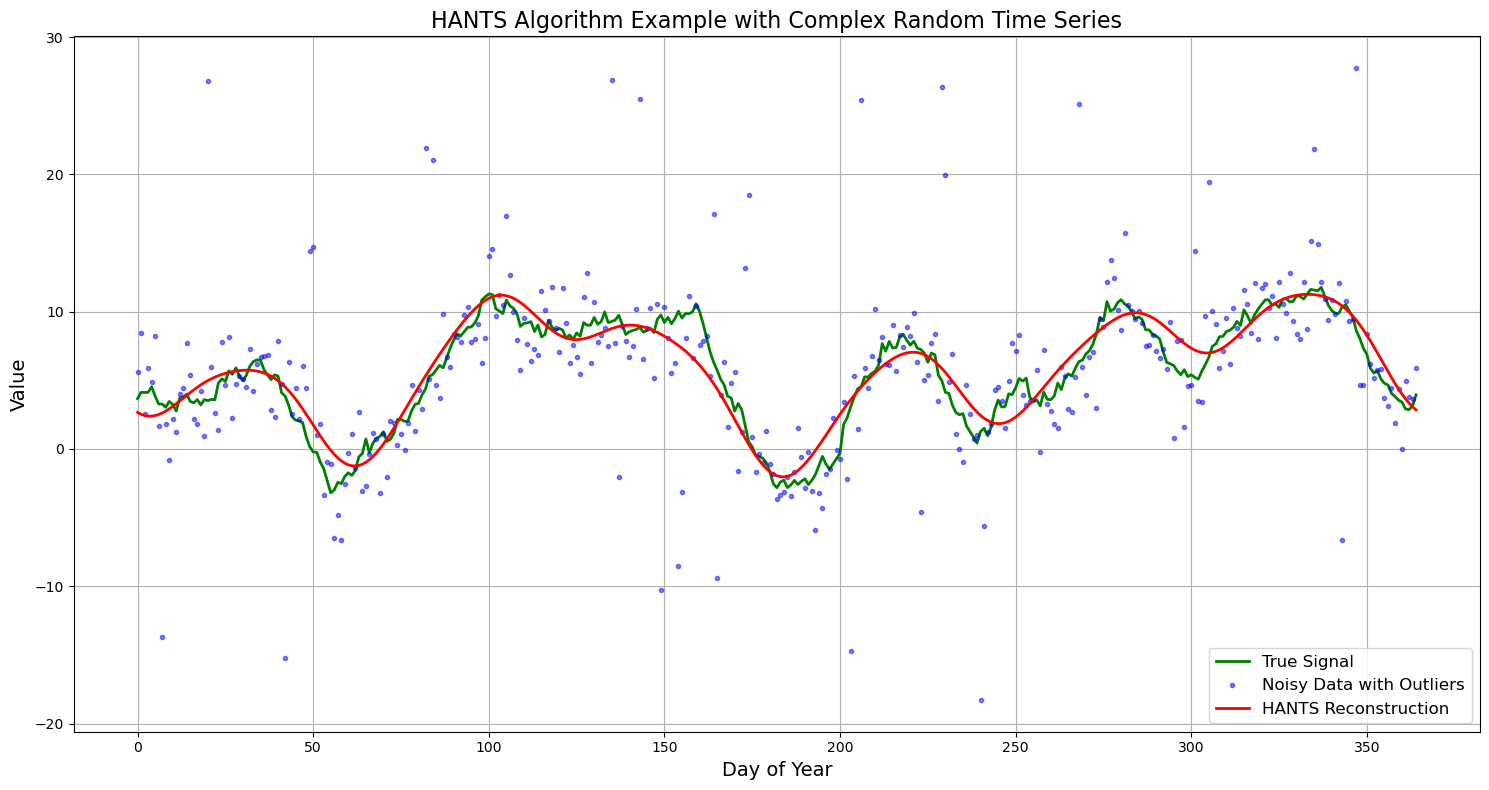

In [18]:
plt.figure(figsize=(15, 8))
plt.plot(days, true_signal, 'g-', label='True Signal', linewidth=2)
plt.plot(days, noisy_signal, 'b.', alpha=0.5, label='Noisy Data with Outliers')
plt.plot(days, rec_signal, 'r-', label='HANTS Reconstruction', linewidth=2)
plt.legend(fontsize=12)
plt.title('HANTS Algorithm Example with Complex Random Time Series', fontsize=16)
plt.xlabel('Day of Year', fontsize=14)
plt.ylabel('Value', fontsize=14)
plt.grid(True)
plt.tight_layout()
plt.show()

In [19]:
print("HANTS Coefficients:")
print(f"Intercept: {intercept:.2f}")
for i in range(num_frequencies):
    print(f"Frequency {frequencies[i]:.4f}: cos_coeff = {cos_coeffs[i]:.2f}, sin_coeff = {sin_coeffs[i]:.2f}, "
          f"Amplitude = {np.sqrt(cos_coeffs[i]**2 + sin_coeffs[i]**2):.2f}, "
          f"Phase = {np.arctan2(sin_coeffs[i], cos_coeffs[i]):.2f}")

HANTS Coefficients:
Intercept: 5.78
Frequency 0.0027: cos_coeff = 0.84, sin_coeff = -0.58, Amplitude = 1.02, Phase = -0.61
Frequency 0.0055: cos_coeff = -1.52, sin_coeff = -3.12, Amplitude = 3.47, Phase = -2.02
Frequency 0.0082: cos_coeff = 1.48, sin_coeff = -0.67, Amplitude = 1.63, Phase = -0.42
Frequency 0.0110: cos_coeff = -0.89, sin_coeff = 1.04, Amplitude = 1.37, Phase = 2.28
Frequency 0.0164: cos_coeff = -2.66, sin_coeff = -0.82, Amplitude = 2.79, Phase = -2.84
Frequency 0.0329: cos_coeff = -0.37, sin_coeff = 0.04, Amplitude = 0.37, Phase = 3.05
